In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
TASKS_PATH = '../data/annotations/20231009_tasks.csv'
ANNOTATIONS_PATH = '../data/annotations/20231009_annotations.csv'
TS_LENGTHS_PATH = '../data/annotations/timeseries_lengths.csv'

In [3]:
def load_datasets():
    annotations = pd.read_csv(ANNOTATIONS_PATH)
    tasks = pd.read_csv(TASKS_PATH)

    # Create dataset column
    annotations.loc[:, 'Dataset'] = annotations['DatasetName'].apply(lambda x: x.split('_')[0])
    tasks.loc[:, 'Dataset'] = tasks['DatasetName'].apply(lambda x: x.split('_')[0])

    # Add synthetic column
    annotations.loc[:, 'Synthetic'] = annotations['DatasetName'].apply(lambda x: ('syn' in x ) or ('shuf' in x))
    tasks.loc[:, 'Synthetic'] = tasks['DatasetName'].apply(lambda x: ('syn' in x ) or ('shuf' in x))

    # Remove the tutorial time series
    annotations = annotations.query('Dataset != "demo"')
    tasks = tasks.query('Dataset != "demo"')

    return annotations, tasks

In [4]:
annotations, tasks = load_datasets()
ts_lengths = pd.read_csv(TS_LENGTHS_PATH, index_col='name')

In [5]:
# Remove sythetic tasks and annotations
annotations = annotations[~annotations['Synthetic']]
tasks = tasks[~tasks['Synthetic']]

# 1. Dataset stats

In [6]:
print('Tot. number of changepoints: ', len(annotations))
print('Number of tasks:', len(tasks))
print('Number of users:', len(tasks['Username'].unique()))
print('Number of datasets:', len(tasks['DatasetName'].unique()))

Tot. number of changepoints:  13892
Number of tasks: 6254
Number of users: 15
Number of datasets: 1397


In [7]:
print('Number of timeseries per system:')
tasks.groupby('Dataset').agg({'DatasetName': 'nunique'})

Number of timeseries per system:


,DatasetName
Dataset,
graal,470
mongodb,461
sap,466


In [8]:
# Number of timeseries per user
ts_per_user = tasks['Username'].value_counts()

# Number of users per timeseries
user_per_ts = tasks['DatasetName'].value_counts()

In [9]:
user_per_ts.value_counts()

5    1154
1      87
2      87
3      53
4      16
Name: DatasetName, dtype: int64

Text(0, 0.5, 'No. Users')

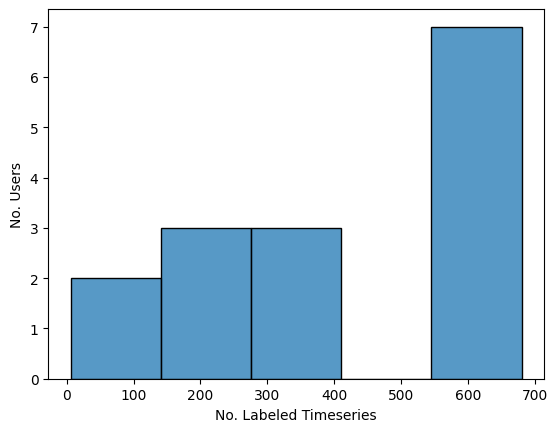

In [10]:
sns.histplot(ts_per_user)
plt.xlabel('No. Labeled Timeseries')
plt.ylabel('No. Users')

# 2. Annotation Evaluation

In [11]:
# Consider only timeseries with 5 annotations

ts_5_annotations = user_per_ts[user_per_ts == 5].index.unique()

annotations = annotations[annotations['DatasetName'].isin(ts_5_annotations)]
tasks = tasks[tasks['DatasetName'].isin(ts_5_annotations)]

In [12]:
print("No. Time Series:", tasks.DatasetName.nunique())


print("No. Change points:", len(annotations[annotations.AnnotationIndex != "no_cp"]))

print("No. Users:", annotations.UserID.nunique())


print("Time series per Dataset:")
print(tasks.groupby('Dataset').agg({'DatasetName': 'nunique'}))


No. Time Series: 1154
No. Change points: 10028
No. Users: 15
Time series per Dataset:
         DatasetName
Dataset             
graal            380
mongodb          383
sap              391


## 2.1. Agreement

In [14]:
from metrics import f_measure, covering

In [15]:
def create_annotation_dict(annotations_ts):
    users = annotations_ts['UserID'].unique()
    annotation_dict = {}

    for user in users:
        annotation_indexes = annotations_ts[annotations_ts['UserID'] == user]['AnnotationIndex'].values
        cpts = [int(i) for i in annotation_indexes if i != 'no_cp']
        annotation_dict[user] = cpts

    return annotation_dict


In [16]:
## Compute agreement between users using one-vs-rest f-measure

res = { 'DatasetName': [], 'UserID': [], 'F-Measure': [], 'Covering': []}


for ts in annotations['DatasetName'].unique():
    # Create annotation dictionary for the current timeseries
    annotations_ts = annotations[annotations['DatasetName'] == ts]
    annotation_dict = create_annotation_dict(annotations_ts)
    users = annotation_dict.keys()

    # Compute f-measure for each user with respect to the others
    for user in users:
        ground_truth = annotation_dict.copy()
        del ground_truth[user]
        
        f1 = f_measure(ground_truth, annotation_dict[user], margin=5)
        n_obs = ts_lengths.loc[ts, 'length']
        cov = covering(ground_truth, annotation_dict[user], n_obs=n_obs)

        res['DatasetName'].append(ts)
        res['UserID'].append(user)
        res['F-Measure'].append(f1)
        res['Covering'].append(cov)

agreement = pd.DataFrame(res)

In [17]:
# one-vs-rest  distribution

def plot_ovr_dist(agreement, metric, filename, label):
    sns.histplot(agreement, x=metric, color ='lightsteelblue',)
    plt.xlabel(metric)

    plt.axvline(agreement[metric].median() , color='dimgray', linestyle='--')
    plt.axvline(agreement[metric].mean() , color='dimgray', linestyle='-')
    # set x axis label
    plt.xlabel(label)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

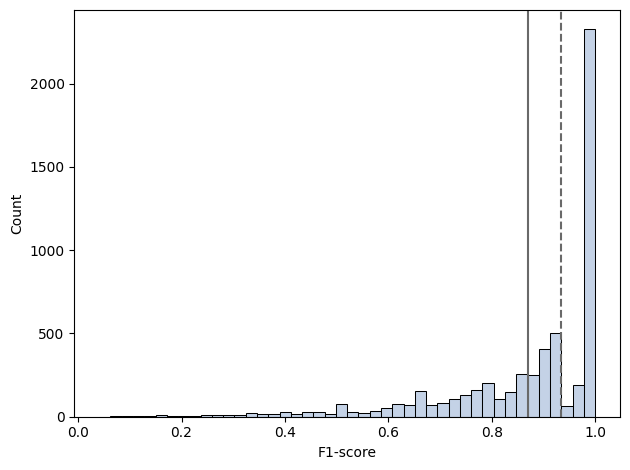

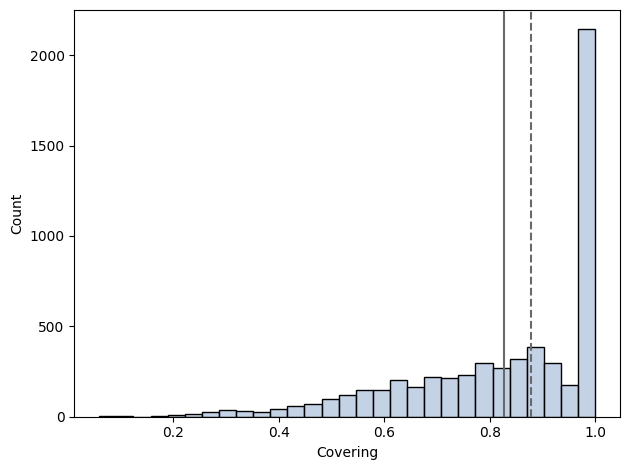

In [18]:
plot_ovr_dist(agreement, "F-Measure", 'figures/ovr-f1.pdf', label='F1-score')
plot_ovr_dist(agreement=agreement, metric="Covering", filename='figures/ovr-covering.pdf', label='Covering')

In [19]:
agreement['F-Measure'].describe()

count    5770.000000
mean        0.870535
std         0.168607
min         0.040816
25%         0.800000
50%         0.933333
75%         1.000000
max         1.000000
Name: F-Measure, dtype: float64

In [20]:
agreement['F-Measure'].value_counts(1)

1.000000    0.398960
0.933333    0.072444
0.909091    0.047660
0.857143    0.025997
0.666667    0.021837
              ...   
0.383838    0.000173
0.373911    0.000173
0.375000    0.000173
0.989474    0.000173
0.831367    0.000173
Name: F-Measure, Length: 881, dtype: float64

In [21]:
agreement['Covering'].describe()

count    5770.000000
mean        0.827431
std         0.188375
min         0.060018
25%         0.709157
50%         0.877403
75%         1.000000
max         1.000000
Name: Covering, dtype: float64

In [22]:
data = {"dataset":[], "cpt":[], "users":[]}

for ts in annotations['DatasetName'].unique():
    annotations_ts = annotations[annotations['DatasetName'] == ts]
    annotation_dict = create_annotation_dict(annotations_ts)

    cpts = [cpt for ctps_ in annotation_dict.values() for cpt in ctps_]
    cpts = np.unique(cpts)
    cpts.sort()

    res = {}
    for cpt in cpts:
        res[cpt] = 0
        for cpts_ in annotation_dict.values():
            for cpt_ in cpts_:
                if abs(cpt - cpt_) <= 5:
                    res[cpt] += 1
                    break
                elif cpt_ > cpt:
                    break
    
    for cpt, users in res.items():
        data['dataset'].append(ts)
        data['cpt'].append(cpt)
        data['users'].append(users)

df = pd.DataFrame(data)

[5815, 3286, 1938, 1212, 618]


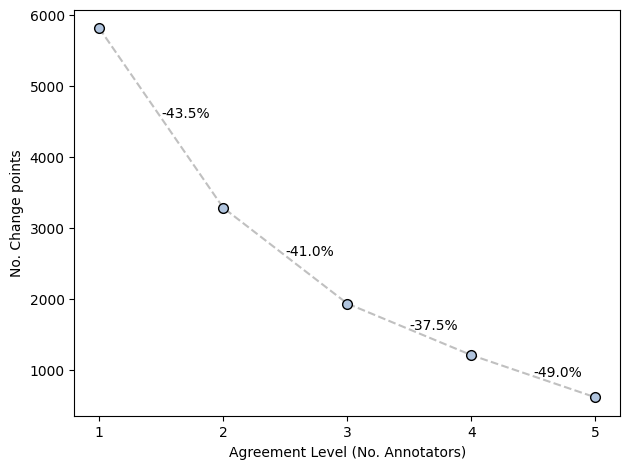

In [23]:
x = range(1, 6)
y = [len(df[df['users'] > x]) for x in range(5)]

print(y)



# sns.lineplot(x=x, y=y, markers=True, marker='o')
# plt.xlabel('Users Agreement')
# plt.ylabel('No. Changepoints')

# Create the line plot with dashed line and dimgray color
sns.lineplot(x=x, y=y, color="silver", linestyle='--')

# Now, plot the data points using plt.plot to have different color for marker and its edge
plt.plot(x, y, marker='o', linestyle='', markersize=7, color="lightsteelblue", markeredgecolor='black')


# Compute the relative differences as percentages
y_diff = np.diff(y) / y[:-1] * 100

# Add the relative difference as text next to the data points
for i, diff in enumerate(y_diff):
    # The x position is the midpoint between two consecutive x points
    x_text = (x[i] + x[i+1]) / 2
    # The y position is the higher of the two y points
    y_text =  (y[i] + y[i+1]) / 2
    # Add the text to the plot
    plt.text(x_text, y_text, f'{diff:.1f}%', horizontalalignment='left')

plt.xticks(x)

plt.xlabel('Agreement Level (No. Annotators)')
plt.ylabel('No. Change points')

plt.tight_layout()
plt.savefig('./figures/agreement-sensitivity.pdf')

In [24]:
df2 = pd.DataFrame()

for nousers in range(1, 6):
    df_ = df[df['users'] >= nousers].groupby('dataset').size().to_frame('nocpt')
    df_['nousers'] = nousers
    df2 = pd.concat([df2, df_])


Text(0, 0.5, 'Users Agreement')

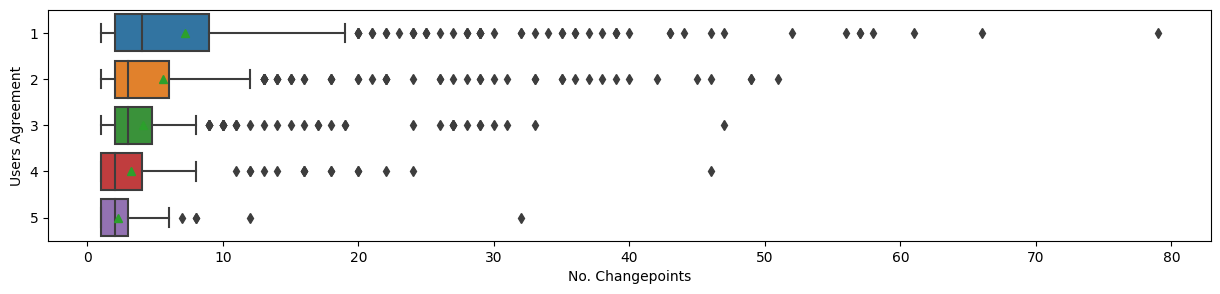

In [25]:
fig, ax = plt.subplots(figsize=(15, 3))
sns.boxplot(y='nousers', x='nocpt', data=df2, showmeans=True, orient='h', ax=ax)

plt.xlabel('No. Changepoints')
plt.ylabel('Users Agreement')

## 2.2 Time Effort

count     5770.000000
mean       101.452268
std       1637.454784
min          1.202000
25%          4.653000
50%         11.530500
75%         28.591750
max      84859.530000
Name: TimeSpentSeconds, dtype: float64


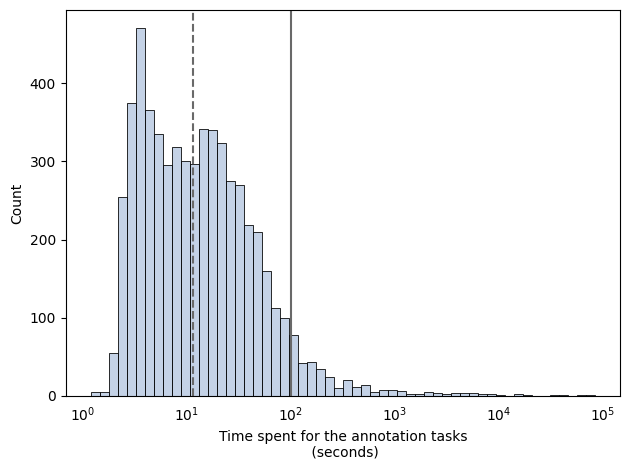

In [26]:

tasks['TimeSpentSeconds'] = tasks['TimeSpent']/1000
sns.histplot(tasks['TimeSpentSeconds'], log_scale=True, color='lightsteelblue')
plt.axvline(tasks['TimeSpentSeconds'].median() , color='dimgray', linestyle='--')
plt.axvline(tasks['TimeSpentSeconds'].mean() , color='dimgray', linestyle='-')

plt.xlabel('Time spent for the annotation tasks\n (seconds)')
plt.tick_params(axis='x', which='both', bottom=False)

plt.tight_layout()

print(tasks['TimeSpentSeconds'].describe())

plt.savefig('figures/annotations-time.pdf')


## 2.3 Difficulty

1    0.034835
2    0.345234
3    0.290468
4    0.287175
5    0.042288
Name: Difficulty, dtype: float64


/var/folders/zx/pcv0zc310vg2l4drkcdxjd7h0000gn/T/ipykernel_12723/3440175952.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()])


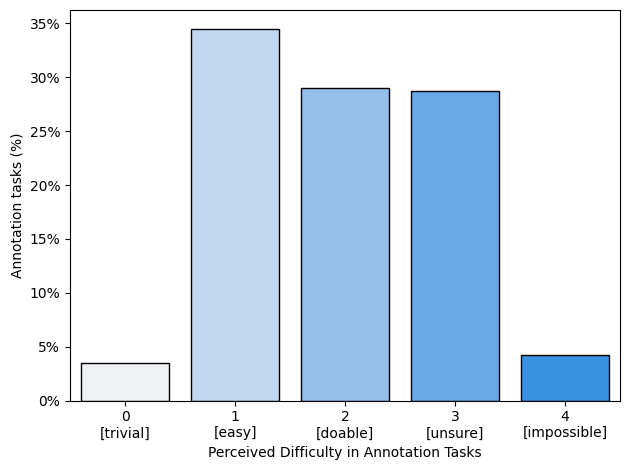

In [27]:
# Create color palette

tasks['Difficulty'] = tasks['Difficulty'].astype(int)
difficulties = tasks['Difficulty'].unique()
colors = sns.light_palette("dodgerblue", difficulties.size)

# Create a countplot and apply the colors
#sns.countplot(x='Difficulty', data=tasks, palette=colors, edgecolor='black')
# Compute percentages
percentages = tasks['Difficulty'].value_counts(normalize=True).sort_index()

print(percentages)

# Plot
ax = sns.barplot(x=percentages.index, y=percentages.values, palette=sns.light_palette("dodgerblue", len(percentages)), edgecolor='black')
ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()])
ax.set_xticklabels([f'{x}\n[{l}]' for x, l in zip(ax.get_xticks(), ['trivial', 'easy', 'doable', 'unsure', 'impossible'])])
ax.set_ylabel('Annotation tasks (%)')
ax.set_xlabel('Perceived Difficulty in Annotation Tasks')
#ax.set(yticklabels=[], ylabel='Annotation tasks (%) ', xlabel='Perceived Difficulty in Annotation Tasks')


plt.tight_layout()

#plt.xlabel('Perceived Difficulty in Annotation Tasks')
plt.savefig('./figures/difficulty.pdf')


### 2.2.1 Correlation between difficulty and time effort

In [28]:
grouped_tasks = tasks.groupby('DatasetName').agg({'Difficulty': 'mean', 'TimeSpent': 'mean'})

Correlation:  0.05085792867392019  p-value:  0.08418232265266035


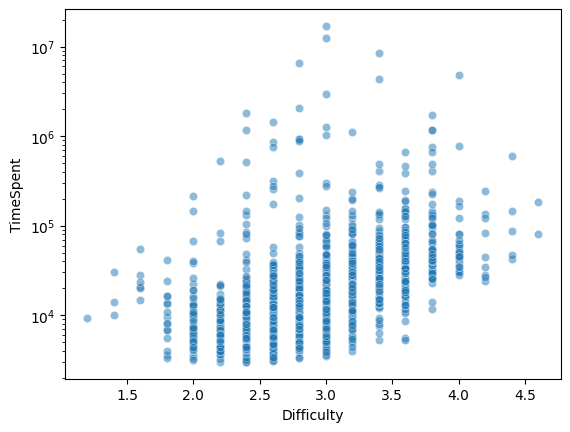

In [29]:
from scipy.stats import pearsonr

corr, p = pearsonr(grouped_tasks['Difficulty'], grouped_tasks['TimeSpent'])

print('Correlation: ', corr, ' p-value: ', p)

sns.scatterplot(x='Difficulty', y='TimeSpent', data=grouped_tasks,alpha=0.5)
plt.yscale('log')

### 2.2.1 Correlation between difficulty and agreement (one-vs-others F1-measure)

In [30]:
grouped_agreement = agreement.groupby('DatasetName').agg({'F-Measure': 'mean', 'Covering':'mean'})
grouped_tasks = grouped_tasks.join(grouped_agreement)

Correlation:  -0.6518633650536776  p-value:  1.4367857149661452e-140


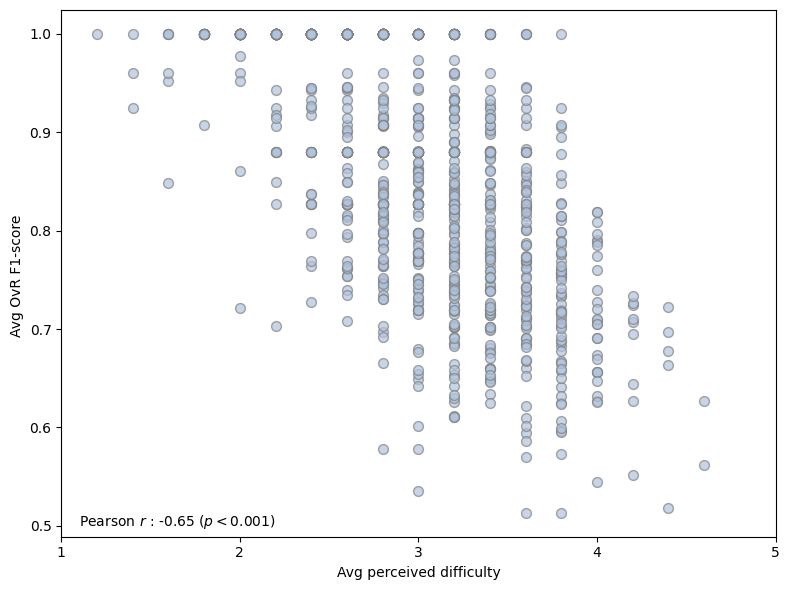

In [31]:
corr, p = pearsonr(grouped_tasks['F-Measure'], grouped_tasks['Difficulty'])

print('Correlation: ', corr, ' p-value: ', p)


fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x=grouped_tasks['Difficulty'], y=grouped_tasks['F-Measure'], 
           s=50, edgecolor='grey', facecolor='lightsteelblue', alpha=0.7)

plt.xticks(tasks['Difficulty'].unique())

plt.xlabel('Avg perceived difficulty')
plt.ylabel('Avg OvR F1-score ')

plt.text(1.1, 0.5, f'Pearson $r$ : {corr:.2f} ($p<0.001$)', horizontalalignment='left')
plt.tight_layout()
plt.savefig('figures/difficulty-vs-f1.pdf')

Correlation:  -0.6498342703440281  p-value:  2.0185746668051663e-139


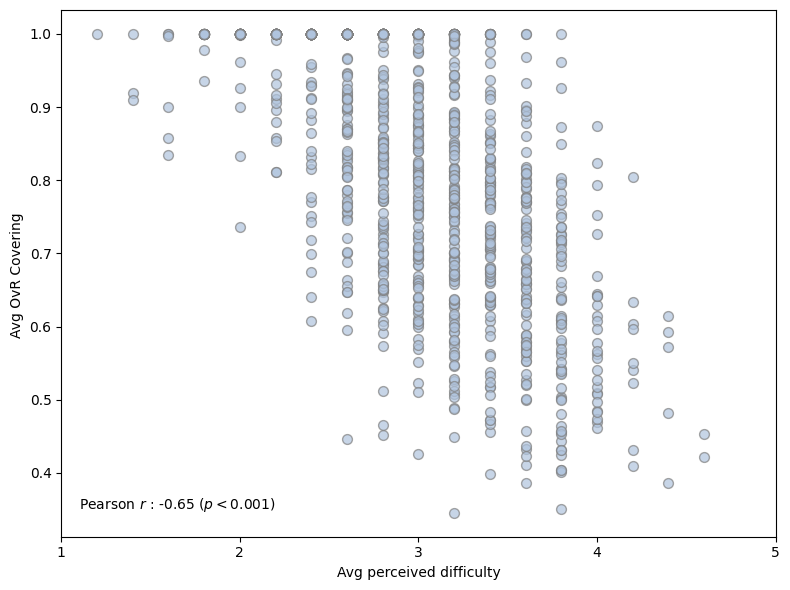

In [32]:
corr, p = pearsonr(grouped_tasks['Covering'], grouped_tasks['Difficulty'])

print('Correlation: ', corr, ' p-value: ', p)


fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x=grouped_tasks['Difficulty'], y=grouped_tasks['Covering'], 
           s=50, edgecolor='grey', facecolor='lightsteelblue', alpha=0.7)

plt.xticks(tasks['Difficulty'].unique())

plt.xlabel('Avg perceived difficulty')
plt.ylabel('Avg OvR Covering ')

plt.text(1.1, 0.35, f'Pearson $r$ : {corr:.2f} ($p<0.001$)', horizontalalignment='left')
plt.tight_layout()
plt.savefig('figures/difficulty-vs-cov.pdf')